# Uvod u znanost o podacima (UZOP) – Projekt – Drugi dio

## Analiza skupa podataka iz znanstvenog članka

U ovom projektu analizira se skup podataka korišten u znanstvenom članku:

**“Early Predictor for Student Success Based on Behavioural and Demographical Indicators”**

Cilj ovog dijela projekta je detaljno upoznavanje sa stvarnim znanstvenim skupom
podataka (OULAD – Open University Learning Analytics Dataset), uključujući:
- učitavanje i pregled podataka
- analizu strukture i tipova podataka
- provjeru kvalitete podataka (nedostajuće i stršeće vrijednosti)
- osnovnu eksploratornu analizu
- pripremu jedinstvenog i očišćenog skupa podataka za daljnju analizu i vizualizaciju
- vizualizacija pripremljenih podataka i postavljanje hipoteza za daljnja istraživanja

Naglasak je na razumijevanju podataka i njihovih karakteristika, a ne na
reprodukciji modela iz samog znanstvenog rada.


In [78]:
import pandas as pd
import numpy as np
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## Učitavanje podataka

Skup podataka OULAD sastoji se od više povezanih CSV datoteka.
U ovom projektu učitavaju se sve dostupne datoteke kako bi se dobio
cjelovit uvid u strukturu i sadržaj podataka.


In [4]:
DATA_PATH = "anonymisedData/"

assessments = pd.read_csv(DATA_PATH + "assessments.csv")
courses = pd.read_csv(DATA_PATH + "courses.csv")
student_assessment = pd.read_csv(DATA_PATH + "studentAssessment.csv")
student_info = pd.read_csv(DATA_PATH + "studentInfo.csv")
student_registration = pd.read_csv(DATA_PATH + "studentRegistration.csv")
student_vle = pd.read_csv(DATA_PATH + "studentVle.csv")
vle = pd.read_csv(DATA_PATH + "vle.csv")

## Osnovni pregled učitanih podataka

U ovom dijelu rada provodi se osnovni pregled svake učitane tablice s ciljem
upoznavanja sa strukturom i sadržajem podataka te procjene koje varijable imaju
smisla koristiti u daljnjoj analizi.

Spajanje tablica, čišćenje podataka, prilagodba vrijednosti za daljnju analizu
te uklanjanje stršećih vrijednosti provodit će se u sljedećim koracima projekta.


In [5]:
datasets = {
    "assessments": assessments,
    "courses": courses,
    "student_assessment": student_assessment,
    "student_info": student_info,
    "student_registration": student_registration,
    "student_vle": student_vle,
    "vle": vle
}

for name, df in datasets.items():
    print(f"{name}: shape = {df.shape}")

assessments: shape = (206, 6)
courses: shape = (22, 3)
student_assessment: shape = (173912, 5)
student_info: shape = (32593, 12)
student_registration: shape = (32593, 5)
student_vle: shape = (10655280, 6)
vle: shape = (6364, 6)


## 1) Analiza tablice `studentInfo`

Tablica `studentInfo` sadrži demografske i administrativne informacije o
studentima koji su pohađali kolegije u Open University sustavu. Svaki redak
predstavlja jednog studenta upisanog na određeni kolegij u određenom terminu.

Opis stupaca:
- `code_module` – oznaka kolegija (npr. AAA, BBB, FFF)
- `code_presentation` – oznaka termina izvođenja (npr. 2013J, 2014J)
- `id_student` – anonimni identifikator studenta
- `gender` – spol studenta (M, F)
- `region` – geografska regija prebivališta studenta
- `highest_education` – najviša razina obrazovanja (npr. A Level, HE Qualification)
- `imd_band` – raspon indeksa socioekonomske deprivacije (npr. 20–30%, 30–40%)
- `age_band` – dobna skupina (0–35, 35–55, 55+)
- `num_of_prev_attempts` – broj prethodnih pokušaja polaganja kolegija
- `studied_credits` – broj ECTS bodova koje student trenutno pohađa
- `disability` – informacija o prijavljenom invaliditetu (Yes / No)
- `final_result` – konačni ishod kolegija (Fail, Pass, Distinction, Withdrawn)

Stupac `final_result` predstavlja ciljnu varijablu u daljnjoj analizi.

In [11]:
# prikaz prvih nekoliko primjera
student_info.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [14]:
# Sažeti pregled kvalitete i osnovne statistike podataka
summary = pd.DataFrame({
    "tip_podatka": student_info.dtypes,
    "nedostajuce_%": (student_info.isnull().mean() * 100).round(2),
    "broj_jedinstvenih": student_info.nunique(),
    "primjer_vrijednosti": student_info.iloc[0]
})

summary

,tip_podatka,nedostajuce_%,broj_jedinstvenih,primjer_vrijednosti
code_module,object,0.00,7,AAA
code_presentation,object,0.00,4,2013J
id_student,int64,0.00,28785,11391
gender,object,0.00,2,M
region,object,0.00,13,East Anglian Region
highest_education,object,0.00,5,HE Qualification
imd_band,object,3.41,10,90-100%
age_band,object,0.00,3,55<=
num_of_prev_attempts,int64,0.00,7,0
studied_credits,int64,0.00,61,240


In [15]:
# Brza provjera raspona numeričkih varijabli
student_info[["num_of_prev_attempts", "studied_credits"]].describe()

,num_of_prev_attempts,studied_credits
count,32593.000000,32593.000000
mean,0.163225,79.758691
std,0.479758,41.071900
min,0.000000,30.000000
25%,0.000000,60.000000
50%,0.000000,60.000000
75%,0.000000,120.000000
max,6.000000,655.000000


### Zaključak – tablica `studentInfo`

Tablica `studentInfo` sadrži ključne demografske i ciljne informacije potrebne
za analizu uspjeha studenata. Podaci su uglavnom potpuni, s malim udjelom
nedostajućih vrijednosti primijećenih u stupcu `imd_band` (~3.4%), što će se
riješiti u fazi čišćenja podataka.

Važno je napomenuti da se ista vrijednost za `id_student` može pojaviti više puta u tablici,
budući da svaki redak predstavlja pohađanje jednog kolegija od strane studenta u određenom terminu.
Drugim riječima, ako je isti student pohađao više različitih kolegija ili isti
kolegij u različitim terminima, to će biti zabilježeno kao zasebni zapisi.

Većina varijabli je kategorijskog tipa, dok su `num_of_prev_attempts` i
`studied_credits` numeričke varijable koje mogu imati prediktivnu vrijednost.
Ova tablica će se koristiti kao osnovna tablica pri spajanju s ostalim
skupovima podataka.



## 2.) Analiza tablice `studentAssessment`

Tablica `studentAssessment` sadrži informacije o rezultatima koje su studenti
ostvarili na pojedinim provjerama znanja. Svaki redak predstavlja
jedan pokušaj rješavanja jedne provjere znanja od strane jednog studenta.

Ova tablica povezuje studente (`id_student`) s konkretnim provjerama znanja
(`id_assessment`) te predstavlja ključnu vezu između aktivnosti studenata
i konačnog ishoda studija.

Opis stupaca:

- `id_assessment` – identifikator provjere znanja (poveznica s tablicom `assessments`)
- `id_student` – anonimni identifikator studenta
- `date_submitted` – dan predaje rada, izražen kao broj dana od početka kolegija
- `is_banked` – označava je li rezultat prenesen iz prethodnog pokušaja (0 = ne, 1 = da)
- `score` – postignuti broj bodova na provjeri znanja (0–100)

Napomena:
- Ako student nije predao zadatak, vrijednost `score` može biti nedostajuća
- Jedan student može imati više redaka u tablici jer polaže više provjera
  znanja unutar istog ili različitih kolegija

In [16]:
student_assessment.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [17]:
# Sažeti pregled kvalitete i osnovnih statistika podataka
summary_student_assessment = pd.DataFrame({
    "tip_podatka": student_assessment.dtypes,
    "nedostajuce_%": (student_assessment.isnull().mean() * 100).round(2),
    "broj_jedinstvenih": student_assessment.nunique(),
    "primjer_vrijednosti": student_assessment.iloc[0]
})

summary_student_assessment

,tip_podatka,nedostajuce_%,broj_jedinstvenih,primjer_vrijednosti
id_assessment,int64,0.0,188,1752.0
id_student,int64,0.0,23369,11391.0
date_submitted,int64,0.0,312,18.0
is_banked,int64,0.0,2,0.0
score,float64,0.1,101,78.0


In [18]:
# Osnovna deskriptivna statistika numeričkih varijabli
student_assessment[["score", "date_submitted"]].describe()

,score,date_submitted
count,173739.000000,173912.000000
mean,75.799573,116.032942
std,18.798107,71.484148
min,0.000000,-11.000000
25%,65.000000,51.000000
50%,80.000000,116.000000
75%,90.000000,173.000000
max,100.000000,608.000000


### Zaključak – tablica `studentAssessment`

Tablica `studentAssessment` sadrži detaljne informacije o uspjehu i ponašanju
studenata na pojedinim provjerama znanja te predstavlja ključni izvor podataka
za ranu predikciju akademskog uspjeha.

Jedan student može imati više zapisa u tablici, budući da tijekom kolegija
rješava više provjera znanja unutar istog ili različitih kolegija.
Stupci `score` i `date_submitted` omogućuju kvantitativni i vremenski uvid u
studentski angažman i dinamiku predaje zadataka.

Manji udio nedostajućih vrijednosti prisutan je u stupcu `score` (~0.1%) i
odnosi se na slučajeve u kojima zadatak nije predan. U daljnjoj analizi takvi
će se zapisi tretirati kao ostvareni rezultat od 0 bodova, budući da
predstavljaju važnu informaciju o neangažiranosti studenta.

Uočene su i rijetke negativne vrijednosti u stupcu `date_submitted`, koje
označavaju predaje prije službenog početka kolegija ili prenesene rezultate
iz prethodnih razdoblja. Takvi zapisi neće se smatrati greškom u podacima,
već će se dodatno interpretirati u kontekstu vremenske analize predaje.

S obzirom na cilj rada "ranu predikciju uspjeha" u nastavku analize
razmatrat će se isključivo **prva provjera znanja** za svaki kolegij i termin
izvođenja. Prva provjera definirat će se kao ona provjera iz tablice
`assessments` s **najranijim službenim rokom predaje (`date`)** unutar
kombinacije `code_module` i `code_presentation`, pri čemu se završni ispiti
isključuju iz razmatranja. Za svakog studenta koristit će se isključivo
rezultat te prve provjere.

Dodatno, usporedbom stvarnog datuma predaje (`date_submitted`) i službenog
roka predaje (`date`) izračunat će se **kašnjenje u predaji**, koje će se
uvrstiti kao nova varijabla ponašanja. Ova varijabla može predstavljati
važan rani indikator angažmana, organizacijskih navika i samoregulacije
studenta, neovisno o samoj ostvarenoj ocjeni.

U sljedećim koracima tablica `studentAssessment` bit će filtrirana,
agregirana na razinu studenta i prve provjere znanja te spojena s tablicama
`studentInfo` i `assessments`, čime će se pripremiti konačni skup podataka
za daljnju analizu i modeliranje.


## 3.) Analiza tablice `assessments`

Tablica `assessments` sadrži metapodatke o svim provjerama znanja unutar
kolegija u OULAD skupu podataka. Svaki redak predstavlja jednu provjeru
znanja (npr. TMA, CMA ili završni ispit) za određeni kolegij i termin izvođenja.

Ova tablica ne sadrži rezultate studenata, već definira strukturu i vremenski
raspored provjera znanja te će se koristiti za povezivanje sa zapisima
u tablici `studentAssessment`.

**Opis stupaca:**

- `code_module` – oznaka kolegija
- `code_presentation` – oznaka termina izvođenja kolegija
- `id_assessment` – jedinstveni identifikator provjere znanja
- `assessment_type` – tip provjere znanja:
  - **TMA (Tutor Marked Assessment)** – zadaci koje ocjenjuje nastavnik i
    koji se rješavaju tijekom trajanja kolegija
  - **CMA (Computer Marked Assessment)** – automatizirani testovi koji se
    ocjenjuju računalno
  - **Exam** – završni ispit, koji se u pravilu vrednuje zasebno
- `date` – krajnji rok predaje izražen kao broj dana od početka kolegija
  (početak kolegija ima vrijednost 0)
- `weight` – težina provjere znanja u ukupnoj ocjeni (u postocima)


In [34]:
# Prikaz prvih nekoliko zapisa
assessments.head(10)

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0
5,AAA,2013J,1757,Exam,NaN,100.0
6,AAA,2014J,1758,TMA,19.0,10.0
7,AAA,2014J,1759,TMA,54.0,20.0
8,AAA,2014J,1760,TMA,117.0,20.0
9,AAA,2014J,1761,TMA,166.0,20.0


In [21]:
# Sažeti pregled kvalitete podataka
summary_assessments = pd.DataFrame({
    "tip_podatka": assessments.dtypes,
    "nedostajuce_%": (assessments.isnull().mean() * 100).round(2),
    "broj_jedinstvenih": assessments.nunique(),
    "primjer_vrijednosti": assessments.iloc[0]
})

summary_assessments

,tip_podatka,nedostajuce_%,broj_jedinstvenih,primjer_vrijednosti
code_module,object,0.00,7,AAA
code_presentation,object,0.00,4,2013J
id_assessment,int64,0.00,206,1752
assessment_type,object,0.00,3,TMA
date,float64,5.34,74,19.0
weight,float64,0.00,24,10.0


In [23]:
# Osnovna statistika numeričkih stupaca
assessments[["date", "weight"]].describe()

,date,weight
count,195.000000,206.000000
mean,145.005128,20.873786
std,76.001119,30.384224
min,12.000000,0.000000
25%,71.000000,0.000000
50%,152.000000,12.500000
75%,222.000000,24.250000
max,261.000000,100.000000


### Zaključak – tablica `assessments`

Tablica `assessments` pruža strukturni i vremenski kontekst svih provjera
znanja unutar kolegija. Posebno je važna za identifikaciju ranih provjera
znanja, budući da stupac `date` omogućuje određivanje kronološkog redoslijeda
provjera unutar pojedinog kolegija i termina izvođenja.

Vrijednosti u stupcu `weight` jasno razdvajaju kontinuirane provjere
znanja (TMA, CMA) od završnog ispita, koji se tretira odvojeno.
U daljnjoj analizi ova će se tablica koristiti za:
- identifikaciju prve provjere znanja po kolegiju,
- filtriranje provjera dostupnih u ranoj fazi kolegija,
- povezivanje sa stvarnim studentskim rezultatima iz tablice
  `studentAssessment`.

Manji udio nedostajućih vrijednosti prisutan je u stupcu `date` (~5.3%) i
uglavnom se odnosi na završne ispite. Budući da se završni ispiti neće
koristiti u kontekstu rane predikcije uspjeha, ove nedostajuće vrijednosti
ne predstavljaju problem za daljnju analizu.

Sama tablica ne zahtijeva dodatno čišćenje, već služi kao referentni skup
podataka pri konstrukciji značajki za ranu predikciju uspjeha.


## 4) Analiza tablice `studentVle`

Tablica `studentVle` sadrži detaljne zapise o interakcijama studenata s
virtualnim nastavnim okruženjem (VLE – Virtual Learning Environment).
Svaki redak predstavlja broj interakcija jednog studenta s određenim
nastavnim materijalom na određeni dan.

Ova tablica predstavlja najbogatiji izvor informacija o studentskom
ponašanju i angažmanu tijekom trajanja kolegija te je ključna za analizu
ranih pokazatelja akademskog uspjeha.

**Opis stupaca:**

- `code_module` – oznaka kolegija
- `code_presentation` – oznaka termina izvođenja kolegija
- `id_student` – anonimni identifikator studenta
- `id_site` – identifikator nastavnog materijala u VLE sustavu
- `date` – dan interakcije izražen kao broj dana od početka kolegija
  (početak kolegija ima vrijednost 0)
- `sum_click` – broj interakcija (klikova) studenta s određenim materijalom
  na taj dan



In [25]:
# Prikaz prvih nekoliko zapisa
student_vle.head(10)

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1
5,AAA,2013J,28400,546652,-10,8
6,AAA,2013J,28400,546876,-10,2
7,AAA,2013J,28400,546688,-10,15
8,AAA,2013J,28400,546662,-10,17
9,AAA,2013J,28400,546890,-10,1


In [26]:
# Sažeti pregled kvalitete podataka
summary_student_vle = pd.DataFrame({
    "tip_podatka": student_vle.dtypes,
    "nedostajuce_%": (student_vle.isnull().mean() * 100).round(2),
    "broj_jedinstvenih": student_vle.nunique(),
    "primjer_vrijednosti": student_vle.iloc[0]
})

summary_student_vle

,tip_podatka,nedostajuce_%,broj_jedinstvenih,primjer_vrijednosti
code_module,object,0.0,7,AAA
code_presentation,object,0.0,4,2013J
id_student,int64,0.0,26074,28400
id_site,int64,0.0,6268,546652
date,int64,0.0,295,-10
sum_click,int64,0.0,498,4


In [27]:
# Osnovna statistika numeričkih stupaca
student_vle[["date", "sum_click"]].describe()

,date,sum_click
count,1.065528e+07,1.065528e+07
mean,9.517400e+01,3.716946e+00
std,7.607130e+01,8.849047e+00
min,-2.500000e+01,1.000000e+00
25%,2.500000e+01,1.000000e+00
50%,8.600000e+01,2.000000e+00
75%,1.560000e+02,3.000000e+00
max,2.690000e+02,6.977000e+03


**Opažanja:**

- Jedan student može imati velik broj zapisa jer ostvaruje više interakcija
  s različitim materijalima tijekom više dana.
- Vrijednosti u stupcu `date` mogu biti negativne, što označava interakcije
  prije službenog početka kolegija (npr. uvodni materijali).
- Distribucija varijable `sum_click` izrazito je asimetrična, s velikim brojem
  malih vrijednosti i rijetkim, vrlo velikim vrijednostima.

### Zaključak – tablica `studentVle`

Tablica `studentVle` pruža detaljan uvid u ponašanje i angažman studenata
u virtualnom nastavnom okruženju te predstavlja ključni izvor značajki
za ranu predikciju akademskog uspjeha.

Velik broj zapisa po studentu odražava vremensku i sadržajnu dinamiku
interakcija, zbog čega će se u daljnjoj analizi podaci agregirati po
studentu i vremenskim razdobljima (npr. prvih nekoliko tjedana kolegija).

S obzirom na cilj rada, fokus će biti na ranim interakcijama studenata.
Varijabla `sum_click` koristit će se kao indikator angažmana, uz napomenu
da veći broj interakcija ne mora nužno značiti i bolji akademski uspjeh,
što će se dodatno istražiti.

Tablica ne zahtijeva trenutno čišćenje, već pripremu i agregaciju podataka
u sljedećoj fazi analize. Nedostajućih vrijednosti nema.



## 5) Analiza tablice `vle`

Tablica `vle` (Virtual Learning Environment) opisuje **nastavne materijale/aktivnosti** dostupne studentima unutar pojedinog kolegija (`code_module`) i termina izvođenja (`code_presentation`). Ona ne sadrži ponašanje studenata (to je u `studentVle`), nego služi kao **referentni katalog sadržaja** kako bismo kasnije mogli grupirati i interpretirati klikove po tipu aktivnosti.

**Opis stupaca (kako tumačiti vrijednosti):**
- `id_site` – jedinstveni ID materijala/stranice u VLE sustavu (npr. određena PDF stranica, forum, quiz, resource…)
- `code_module` – oznaka kolegija kojem materijal pripada
- `code_presentation` – oznaka termina izvođenja kolegija
- `activity_type` – tip aktivnosti/materijala (npr. `resource`, `subpage`, forum, quiz, …); ovo je najkorisniji stupac za kasniju agregaciju klikova
- `week_from` – od kojeg tjedna se materijal planirano koristi (često nedostaje; više “plan” nego stvarna upotreba)
- `week_to` – do kojeg tjedna se materijal planirano koristi (također često nedostaje)


In [28]:
# prikaz prvih nekoliko redaka
vle.head()

,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


In [29]:
# sažeti pregled kvalitete i osnovnih informacija po stupcima
summary_vle = pd.DataFrame({
    "tip_podatka": vle.dtypes,
    "nedostajuce_%": (vle.isnull().mean() * 100).round(2),
    "broj_jedinstvenih": vle.nunique(),
    "primjer_vrijednosti": vle.iloc[0]
})
summary_vle

,tip_podatka,nedostajuce_%,broj_jedinstvenih,primjer_vrijednosti
id_site,int64,0.00,6364,546943
code_module,object,0.00,7,AAA
code_presentation,object,0.00,4,2013J
activity_type,object,0.00,20,resource
week_from,float64,82.39,30,NaN
week_to,float64,82.39,30,NaN


### Zaključak – tablica `vle`

Tablica `vle` služi kao **referentna tablica** koja daje kontekst nastavnim
materijalima u virtualnom okruženju za učenje. Pomoću stupca `id_site`
omogućuje smisleno povezivanje s tablicom `studentVle` i agregiranje
studentskih klikova po tipu aktivnosti.

Za ranu predikciju uspjeha najkorisniji su stupci:
- `id_site` (povezivanje sa `studentVle`)
- `activity_type` (grupiranje interakcija po vrsti aktivnosti)
- `code_module` i `code_presentation` (spajanje po kolegiju i terminu)

Stupci `week_from` i `week_to` opisuju planirani, a ne stvarni raspon
korištenja materijala te zbog velikog udjela nedostajućih vrijednosti
nemaju visoku analitičku vrijednost.

U nastavku će se tablica `vle` koristiti prvenstveno za mapiranje
`id_site → activity_type`, kako bi se interakcije iz `studentVle`
pretvorile u smislenije indikatore angažmana studenata.


## 6) Analiza tablice `studentRegistration`

Tablica `studentRegistration` sadrži informacije o vremenu registracije i
eventualnog ispisivanja studenata s kolegija. Služi kao pomoćni izvor
podataka za razumijevanje **trajanja sudjelovanja studenta u kolegiju** te
ranog odustajanja (withdrawal).

Svaki redak predstavlja jednog studenta upisanog na određeni kolegij u
određenom terminu izvođenja.

### Opis stupaca

- `code_module` – oznaka kolegija
- `code_presentation` – oznaka termina izvođenja kolegija
- `id_student` – anonimni identifikator studenta
- `date_registration` – dan registracije studenta, izražen kao broj dana
  relativno u odnosu na početak kolegija (0 = početak kolegija)
- `date_unregistration` – dan ispisa studenta s kolegija (ako postoji),
  također izražen relativno u odnosu na početak kolegija

Negativne vrijednosti označavaju događaje **prije službenog početka kolegija**
(npr. rana registracija).


In [33]:
# prikaz prvih nekoliko zapisa
student_registration.head()

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


### Zaključak – tablica `studentRegistration`

Tablica `studentRegistration` pruža vremenski kontekst vezan uz upis studenata
na kolegij te je relevantna za ranu fazu kolegija. Posebno je važan stupac
`date_registration`, koji autori izvornog rada koriste kao jednu od ranih
značajki, budući da odražava koliko se rano student uključio u kolegij.

Vrijeme registracije može biti indikator početne motivacije i organiziranosti
studenta, što ga čini potencijalno korisnim prediktorom akademskog uspjeha u
ranim fazama kolegija.

Stupac `date_unregistration` označava ispis studenta s kolegija. Iako ta
informacija može signalizirati neuspjeh, u kontekstu ovog rada ona je
potencijalno **redundantna**, budući da je konačni ishod kolegija već sadržan
u ciljnoj varijabli `final_result`. Zbog toga se `date_unregistration` neće
koristiti kao ulazna značajka u modelima rane predikcije.

U daljnjoj analizi tablica `studentRegistration` koristit će se primarno kao
dopunski izvor vremenskih informacija, s fokusom na `date_registration`, te
će se povezati s ostalim tablicama radi konstrukcije ranih prediktivnih
značajki.


## 7) tablica `courses`

Tablica `courses` sadrži osnovne strukturne informacije o kolegijima i njihovim
terminima izvođenja. Glavna uloga ove tablice je pružanje konteksta za ostale
skupove podataka, osobito pri ispravnom spajanju po kombinaciji
`code_module` i `code_presentation`.

Stupac `module_presentation_length` opisuje ukupno trajanje kolegija u danima.
Budući da se duljina kolegija između različitih modula ne razlikuje značajno,
ova varijabla vjerojatno nema veliku prediktivnu vrijednost za ranu analizu,
ali može poslužiti kao pomoćna informacija pri interpretaciji vremenskih
značajki.

Tablica `courses` neće se koristiti za izravnu konstrukciju prediktivnih
značajki, već prvenstveno kao **referentna tablica** za povezivanje i
kontekstualizaciju ostalih skupova podataka.


In [35]:
# prikaz prvih nekoliko redaka
courses.head()

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240


# Definicija značajki i konstrukcija analitičke tablice (rani prediktori uspjeha)

U ovoj sekciji definiramo varijable za **ranu predikciju uspjeha**. Uključujemo značajke iz izvornog rada (radi replikacije i usporedbe), te dodajemo nekoliko dodatnih značajki koje mogu poboljšati rezultate.

Cilj je objediniti podatke iz više tablica u jednu analitičku tablicu s:
- demografijom i administrativnim podacima,
- ranim signalima uspjeha (prva provjera znanja),
- ranim signalima angažmana (VLE klikovi/aktivnost),
- ciljnom varijablom (`final_result`).

---

## Odabrane varijable

### 1) Varijable iz izvornog rada

**`studentInfo`:**
- `highest_education`, `age_band`, `gender`, `disability`, `num_of_prev_attempts`

**`studentRegistration`:**
- `date_registration` (dani u odnosu na početak kolegija)

**`studentAssessment` + `assessments`:**
- `score_first_assessment` (rezultat na prvoj provjeri znanja)

**`studentVle`:**
- `clicks_till_course_starts` (ukupni klikovi za `date < 0`)

### 2) Dodatne varijable (proširenje)

**Rani angažman do prve provjere:**
- `clicks_from_course_start_until_first_assessment`
- `active_days_before_course_start`
- `active_days_from_course_start_until_first_assessment`

*(opcionalno) po `activity_type`:*
- `clicks_resource`, `clicks_forum`, `clicks_quiz`

**Kašnjenje prve predaje:**
- `delay_first_assessment = date_submitted - assessment_date`

**Kontekst prve provjere:**
- `first_assessment_type` (TMA/CMA)

---

## Kako određujemo “prvu provjeru znanja”

Za svaki (`code_module`, `code_presentation`) prva provjera je ona s **najmanjim `date`** u tablici `assessments` (uz fokus na TMA/CMA). Zatim se u `studentAssessment` uzimaju rezultati studenata za taj `id_assessment`.

---

## Što ne koristimo (i zašto)

- `date_unregistration`: može biti kasni signal i djelomično redundantno s ishodom.
- indikator predaje: ne uvodimo posebno jer se **nedostajući `score` tretira kao 0** (nepredano = relevantna informacija).

---

## Završna analitička tablica

**Naziv:** `early_predictors`
**1 redak:** 1 student × 1 kolegij (`code_module`) × 1 termin (`code_presentation`)
Tablica sadrži identifikatore, odabrane značajke i cilj (`final_result`) te služi kao ulaz za daljnju analizu i modeliranje.


In [36]:
# upozorenje: ide jedan stvarno VELIK komad koda

In [43]:
# KONFIGURACIJA
ACTIVE_CLICK_THRESHOLD = 0   # "aktivan dan" = sum_click > ACTIVE_CLICK_THRESHOLD (0 znači >0)
CAP_WINDOW_DAYS = None       # npr. 14 za cap (0..min(first_assessment_date, 14)); None = bez capa
INCLUDE_ACTIVITY_TYPE_FEATURES = False
ACTIVITY_TYPES_TO_KEEP = ["resource", "forum", "quiz"]  # opcionalno i proširivo

# 0) POMOĆNE FUNKCIJE
def _active_day_mask(click_series: pd.Series, threshold: int = 0) -> pd.Series:
    """Aktivan dan = sum_click > threshold (default threshold=0)."""
    return click_series > threshold

def _apply_cap(first_date: pd.Series, cap: int | None) -> pd.Series:
    """Ako je CAP_WINDOW_DAYS postavljen, skraćuje first_assessment_date na min(first_date, cap)."""
    if cap is None:
        return first_date
    return np.minimum(first_date, cap)

# 1) PRIPREMA / "DUKATI" (agregacije koje uklanjaju duple logičke zapise)
vle_ref = (
    vle.drop_duplicates(subset=["code_module", "code_presentation", "id_site"])
      .loc[:, ["code_module", "code_presentation", "id_site", "activity_type", "week_from", "week_to"]]
)

reg_agg = (
    student_registration
    .groupby(["id_student", "code_module", "code_presentation"], as_index=False)
    .agg(date_registration=("date_registration", "min"),
         date_unregistration=("date_unregistration", "min"))  # ostavljamo kao pomoćno; ne koristimo kao feature
)

svle_clean = (
    student_vle
    .groupby(["id_student", "code_module", "code_presentation", "id_site", "date"], as_index=False)
    .agg(sum_click=("sum_click", "sum"))
)


# 2) ODREĐIVANJE "PRVE PROVJERE" (TMA/CMA s najmanjim date po kolegiju/terminu)
assessments_clean = assessments.copy()

first_assessment_map = (
    assessments_clean
    .loc[assessments_clean["assessment_type"].isin(["TMA", "CMA"]) & assessments_clean["date"].notna(),
         ["code_module", "code_presentation", "id_assessment", "assessment_type", "date"]]
    .sort_values(["code_module", "code_presentation", "date", "id_assessment"])
    .groupby(["code_module", "code_presentation"], as_index=False)
    .first()
    .rename(columns={
        "id_assessment": "first_assessment_id",
        "assessment_type": "first_assessment_type",
        "date": "first_assessment_date"
    })
)

first_assessment_map["first_assessment_date_capped"] = _apply_cap(
    first_assessment_map["first_assessment_date"].astype(float), CAP_WINDOW_DAYS
)

# 3) PRVA PROVJERA - REZULTAT I KAŠNJENJE (studentAssessment + assessments)
sa_enriched = (
    student_assessment
    .merge(
        assessments_clean[["id_assessment", "code_module", "code_presentation", "assessment_type", "date"]],
        on="id_assessment",
        how="left"
    )
    .rename(columns={"date": "assessment_date"})
)

sa_first = (
    sa_enriched
    .merge(first_assessment_map[["code_module", "code_presentation", "first_assessment_id"]],
           on=["code_module", "code_presentation"],
           how="inner")
)

sa_first = sa_first.loc[sa_first["id_assessment"] == sa_first["first_assessment_id"]].copy()
sa_first["score"] = sa_first["score"].fillna(0)

# rješavanje duplikata
sa_first = (
    sa_first
    .sort_values(["id_student", "code_module", "code_presentation", "id_assessment", "score", "date_submitted"])
    .groupby(["id_student", "code_module", "code_presentation", "id_assessment"], as_index=False)
    .tail(1)
)
# derivacije
sa_first = sa_first.rename(columns={"score": "score_first_assessment", "date_submitted": "date_submitted_first"})
sa_first["delay_first_assessment"] = sa_first["date_submitted_first"] - sa_first["assessment_date"]
# zadrži samo relevantne stupce
sa_features = sa_first.loc[:, [
    "id_student", "code_module", "code_presentation",
    "score_first_assessment", "date_submitted_first", "assessment_date", "delay_first_assessment"
]]

# 4) VLE FEATUREI (klikovi i aktivni dani)
svle_mapped = svle_clean.merge(
    vle_ref[["code_module", "code_presentation", "id_site", "activity_type"]],
    on=["code_module", "code_presentation", "id_site"],
    how="left"
)

pre_mask = svle_mapped["date"] < 0
pre_part = svle_mapped.loc[pre_mask].copy()
pre_features = (
    pre_part
    .groupby(["id_student", "code_module", "code_presentation"], as_index=False)
    .agg(
        clicks_till_course_starts=("sum_click", "sum"),
        active_days_before_course_start=("date", lambda s: s[_active_day_mask(pre_part.loc[s.index, "sum_click"], ACTIVE_CLICK_THRESHOLD)].nunique())
    )
)

svle_with_first = svle_mapped.merge(
    first_assessment_map[["code_module", "code_presentation", "first_assessment_date_capped"]],
    on=["code_module", "code_presentation"],
    how="left"
)

win_mask = (svle_with_first["date"] >= 0) & (svle_with_first["date"] <= svle_with_first["first_assessment_date_capped"])
win_part = svle_with_first.loc[win_mask].copy()

window_features = (
    win_part
    .groupby(["id_student", "code_module", "code_presentation"], as_index=False)
    .agg(
        clicks_from_course_start_until_first_assessment=("sum_click", "sum"),
        active_days_from_course_start_until_first_assessment=("date", lambda s: s[_active_day_mask(win_part.loc[s.index, "sum_click"], ACTIVE_CLICK_THRESHOLD)].nunique())
    )
)

activity_pivot = None
if INCLUDE_ACTIVITY_TYPE_FEATURES:
    win_part_at = win_part.loc[win_part["activity_type"].isin(ACTIVITY_TYPES_TO_KEEP)].copy()

    activity_pivot = (
        win_part_at
        .groupby(["id_student", "code_module", "code_presentation", "activity_type"], as_index=False)
        .agg(clicks=("sum_click", "sum"))
        .pivot_table(index=["id_student", "code_module", "code_presentation"],
                     columns="activity_type",
                     values="clicks",
                     fill_value=0)
        .reset_index()
    )

    activity_pivot.columns = [
        f"clicks_{c}" if c in ACTIVITY_TYPES_TO_KEEP else c for c in activity_pivot.columns
    ]

# 5) DEMOGRAFIJA + CILJ (studentInfo) + REGISTRACIJA
base_cols = [
    "id_student", "code_module", "code_presentation",
    "highest_education", "age_band", "gender", "disability", "num_of_prev_attempts",
    "final_result"
]
base = student_info.loc[:, base_cols].copy()

# 6) SPAJANJE U JEDNU ANALITIČKU TABLICU: early_predictors
early_predictors = (
    base
    .merge(reg_agg[["id_student", "code_module", "code_presentation", "date_registration"]],
           on=["id_student", "code_module", "code_presentation"], how="left")
    .merge(first_assessment_map[["code_module", "code_presentation", "first_assessment_type", "first_assessment_date"]],
           on=["code_module", "code_presentation"], how="left")
    .merge(sa_features.drop(columns=["assessment_date"]),  # assessment_date je isto što i first_assessment_date (rok)
           on=["id_student", "code_module", "code_presentation"], how="left")
    .merge(pre_features,
           on=["id_student", "code_module", "code_presentation"], how="left")
    .merge(window_features,
           on=["id_student", "code_module", "code_presentation"], how="left")
)

if INCLUDE_ACTIVITY_TYPE_FEATURES and activity_pivot is not None:
    early_predictors = early_predictors.merge(
        activity_pivot, on=["id_student", "code_module", "code_presentation"], how="left"
    )

vle_agg_cols = [
    "clicks_till_course_starts",
    "active_days_before_course_start",
    "clicks_from_course_start_until_first_assessment",
    "active_days_from_course_start_until_first_assessment",
]
for c in vle_agg_cols:
    if c in early_predictors.columns:
        early_predictors[c] = early_predictors[c].fillna(0)

if INCLUDE_ACTIVITY_TYPE_FEATURES:
    for c in [f"clicks_{t}" for t in ACTIVITY_TYPES_TO_KEEP]:
        if c in early_predictors.columns:
            early_predictors[c] = early_predictors[c].fillna(0)

early_predictors["score_first_assessment"] = early_predictors["score_first_assessment"].fillna(0)

# 7) SPREMANJE
key_cols = ["id_student", "code_module", "code_presentation"]
other_cols = [c for c in early_predictors.columns if c not in key_cols]
early_predictors = early_predictors.loc[:, key_cols + other_cols]

print("Kreirana tablica:", OUTPUT_NAME)
print("Shape:", early_predictors.shape)

early_predictors.head()

Kreirana tablica: early_predictors
Shape: (32593, 19)


,id_student,code_module,code_presentation,highest_education,age_band,gender,disability,num_of_prev_attempts,final_result,date_registration,first_assessment_type,first_assessment_date,score_first_assessment,date_submitted_first,delay_first_assessment,clicks_till_course_starts,active_days_before_course_start,clicks_from_course_start_until_first_assessment,active_days_from_course_start_until_first_assessment
0,11391,AAA,2013J,HE Qualification,55<=,M,N,0,Pass,-159.0,TMA,19.0,78.0,18.0,-1.0,98.0,1.0,303.0,7.0
1,28400,AAA,2013J,HE Qualification,35-55,F,N,0,Pass,-53.0,TMA,19.0,70.0,22.0,3.0,215.0,7.0,278.0,8.0
2,30268,AAA,2013J,A Level or Equivalent,35-55,F,Y,0,Withdrawn,-92.0,TMA,19.0,0.0,NaN,NaN,102.0,6.0,179.0,6.0
3,31604,AAA,2013J,A Level or Equivalent,35-55,F,N,0,Pass,-52.0,TMA,19.0,72.0,17.0,-2.0,169.0,5.0,275.0,11.0
4,32885,AAA,2013J,Lower Than A Level,0-35,F,N,0,Pass,-176.0,TMA,19.0,69.0,26.0,7.0,295.0,8.0,204.0,11.0


In [44]:
early_predictors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 19 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   id_student                                            32593 non-null  int64  
 1   code_module                                           32593 non-null  object 
 2   code_presentation                                     32593 non-null  object 
 3   highest_education                                     32593 non-null  object 
 4   age_band                                              32593 non-null  object 
 5   gender                                                32593 non-null  object 
 6   disability                                            32593 non-null  object 
 7   num_of_prev_attempts                                  32593 non-null  int64  
 8   final_result                                          32

## Finalni odabir stupaca i uklanjanje redundantnih varijabli

Nakon dodatnog pregleda konstruirane analitičke tablice donesena je odluka
o zadržavanju svih varijabli koje imaju jasnu interpretaciju i smisao u
kontekstu rane predikcije uspjeha studenata.

Posebna pažnja posvećena je uklanjanju varijabli koje:
- ne donose novu informaciju u odnosu na već postojeće značajke,
- predstavljaju sirove vremenske podatke čija je informacija već sažeta
  u izvedenim varijablama,
- mogu unijeti šum ili pristranost zbog razlika u rasporedu među kolegijima.

### Uklonjene varijable

Iz skupa podataka uklonjene su sljedeće varijable:

- **`first_assessment_date`**
  Ova varijabla predstavlja krajnji rok prve provjere znanja izražen u danima
  od početka kolegija. Budući da su rani pokazatelji angažmana već definirani
  isključivo do prve provjere znanja, sama vrijednost roka nije potrebna za
  daljnju analizu. Zadržavanje ove varijable moglo bi unijeti pristranost jer
  se rasporedi razlikuju među kolegijima.

- **`date_submitted_first`**
  Ova varijabla označava stvarni dan predaje prve provjere znanja. Informacija
  o pravovremenosti predaje već je u potpunosti sadržana u varijabli
  **`delay_first_assessment`**, koja mjeri koliko je student predao ranije ili
  kasnije u odnosu na rok. Zadržavanje oba stupca bilo bi redundantno.

### Zaključak

Nakon uklanjanja navedenih varijabli zadržane su sve ključne značajke koje
opisuju:
- demografske i administrativne karakteristike studenata,
- rani akademski uspjeh (prva provjera znanja),
- rani angažman u virtualnom okruženju za učenje,
- ciljnu varijablu (`final_result`).

Dobiveni skup podataka predstavlja čistu i konzistentnu osnovu za daljnju
analizu i modeliranje.


In [45]:
df = early_predictors.copy()

DROP_COLUMNS = [
    "first_assessment_date",
    "date_submitted_first"
]

df = df.drop(columns=[c for c in DROP_COLUMNS if c in df.columns])

# Ja bi reko smisleni redoslijed stupaca
COLUMN_ORDER = [
    # Identifikatori
    "id_student", "code_module", "code_presentation",
    # Ciljna varijabla
    "final_result",
    # Demografija i background
    "highest_education", "age_band", "gender", "disability",
    "num_of_prev_attempts", "date_registration",
    # Prva provjera znanja
    "score_first_assessment", "delay_first_assessment", "first_assessment_type",
    # Rani angažman (VLE)
    "clicks_till_course_starts",
    "active_days_before_course_start",
    "clicks_from_course_start_until_first_assessment",
    "active_days_from_course_start_until_first_assessment"
]

COLUMN_ORDER = [c for c in COLUMN_ORDER if c in df.columns]
df = df[COLUMN_ORDER]

OUTPUT_DIR = "processed_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

csv_path = os.path.join(OUTPUT_DIR, "early_predictors_final.csv")
parquet_path = os.path.join(OUTPUT_DIR, "early_predictors_final.parquet")

df.to_csv(csv_path, index=False)
df.to_parquet(parquet_path, index=False)

print("Finalni skup podataka spremljen")
print("CSV:", csv_path)
print("Parquet:", parquet_path)
print("Shape:", df.shape)

df.head()

Finalni skup podataka spremljen
CSV: processed_data/early_predictors_final.csv
Parquet: processed_data/early_predictors_final.parquet
Shape: (32593, 17)


,id_student,code_module,code_presentation,final_result,highest_education,age_band,gender,disability,num_of_prev_attempts,date_registration,score_first_assessment,delay_first_assessment,first_assessment_type,clicks_till_course_starts,active_days_before_course_start,clicks_from_course_start_until_first_assessment,active_days_from_course_start_until_first_assessment
0,11391,AAA,2013J,Pass,HE Qualification,55<=,M,N,0,-159.0,78.0,-1.0,TMA,98.0,1.0,303.0,7.0
1,28400,AAA,2013J,Pass,HE Qualification,35-55,F,N,0,-53.0,70.0,3.0,TMA,215.0,7.0,278.0,8.0
2,30268,AAA,2013J,Withdrawn,A Level or Equivalent,35-55,F,Y,0,-92.0,0.0,NaN,TMA,102.0,6.0,179.0,6.0
3,31604,AAA,2013J,Pass,A Level or Equivalent,35-55,F,N,0,-52.0,72.0,-2.0,TMA,169.0,5.0,275.0,11.0
4,32885,AAA,2013J,Pass,Lower Than A Level,0-35,F,N,0,-176.0,69.0,7.0,TMA,295.0,8.0,204.0,11.0


# Eksplorativna analiza podataka (EDA)

U ovom poglavlju provodi se eksplorativna analiza konačnog skupa podataka
`early_predictors_final` s ciljem boljeg razumijevanja raspodjele podataka,
međusobnih odnosa značajki te potencijalnih ranih indikatora akademskog
uspjeha studenata.

Analiza uključuje osnovnu deskriptivnu statistiku, vizualizacije ključnih
značajki, analizu korelacija te pregled nedostajućih vrijednosti.


## Osnovni pregled skupa podataka

U nastavku se provodi osnovni pregled strukture podataka, tipova varijabli
te raspodjele ciljne varijable.


In [46]:
print("Shape:", df.shape)
df.info()

Shape: (32593, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 17 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   id_student                                            32593 non-null  int64  
 1   code_module                                           32593 non-null  object 
 2   code_presentation                                     32593 non-null  object 
 3   final_result                                          32593 non-null  object 
 4   highest_education                                     32593 non-null  object 
 5   age_band                                              32593 non-null  object 
 6   gender                                                32593 non-null  object 
 7   disability                                            32593 non-null  object 
 8   num_of_prev_attempts                 

## Raspodjela ciljne varijable

Prvo se analizira raspodjela ciljne varijable `final_result`, kako bi se
utvrdila uravnoteženost klasa i potencijalni problemi s neuravnoteženim
skupom podataka.

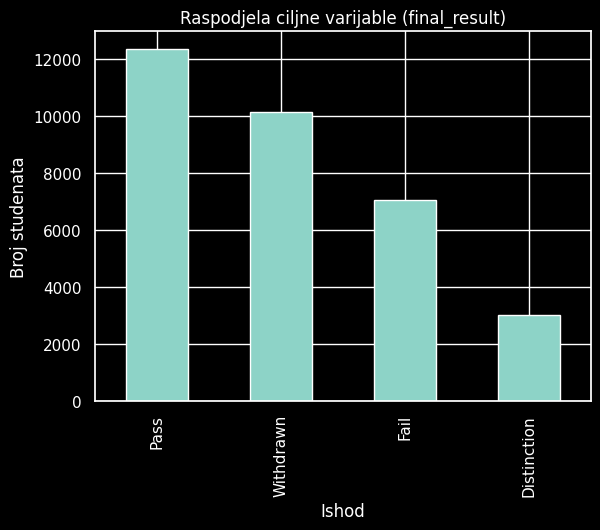

In [51]:
import matplotlib.pyplot as plt

df["final_result"].value_counts().plot(kind="bar")
plt.title("Raspodjela ciljne varijable (final_result)")
plt.xlabel("Ishod")
plt.ylabel("Broj studenata")
plt.show()

## Deskriptivna statistika numeričkih značajki

U ovom dijelu prikazuje se osnovna deskriptivna statistika numeričkih
značajki koje predstavljaju rane indikatore uspjeha i angažmana.

In [48]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[numeric_cols].describe().round(2)

,id_student,num_of_prev_attempts,date_registration,score_first_assessment,delay_first_assessment,clicks_till_course_starts,active_days_before_course_start,clicks_from_course_start_until_first_assessment,active_days_from_course_start_until_first_assessment
count,32593.00,32593.00,32548.00,32593.00,25385.00,32593.00,32593.00,32593.00,32593.00
mean,706687.67,0.16,-69.41,56.74,-1.49,65.90,3.31,210.83,8.07
std,549167.31,0.48,49.26,35.63,6.67,129.25,3.83,270.88,6.70
min,3733.00,0.00,-322.00,0.00,-62.00,0.00,0.00,0.00,0.00
25%,508573.00,0.00,-100.00,14.00,-3.00,0.00,0.00,29.00,3.00
50%,590310.00,0.00,-57.00,70.00,-1.00,19.00,2.00,124.00,7.00
75%,644453.00,0.00,-29.00,84.00,0.00,76.00,5.00,294.00,12.00
max,2716795.00,6.00,167.00,100.00,198.00,3731.00,25.00,5643.00,62.00


## Rani uspjeh i kašnjenje prve provjere znanja

Analizira se odnos rezultata prve provjere znanja (`score_first_assessment`)
i kašnjenja (`delay_first_assessment`) s konačnim ishodom kolegija.


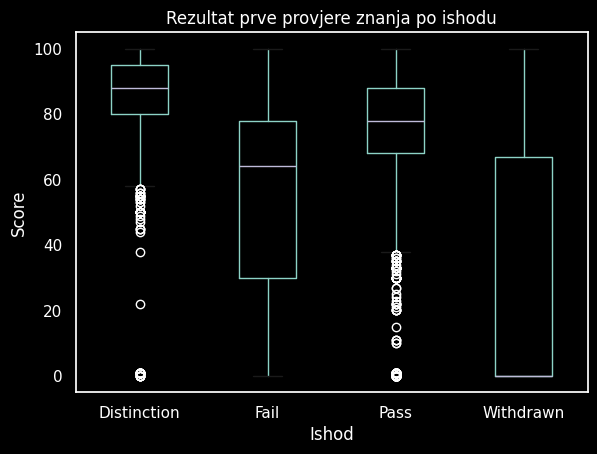

In [55]:
df.boxplot(column="score_first_assessment", by="final_result")
plt.title("Rezultat prve provjere znanja po ishodu")
plt.suptitle("")
plt.xlabel("Ishod")
plt.ylabel("Score")
plt.grid(False)
plt.show()

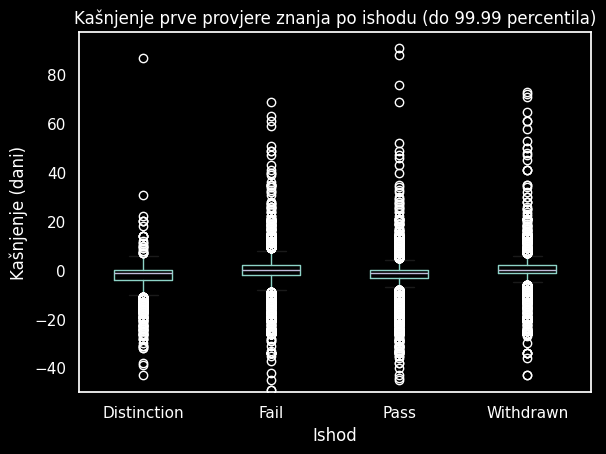

In [66]:
y = df["delay_first_assessment"].dropna()
upper = np.percentile(y, 99.99)

df.boxplot(column="delay_first_assessment", by="final_result")
plt.ylim(-50, upper)
plt.title("Kašnjenje prve provjere znanja po ishodu (do 99.99 percentila)")
plt.suptitle("")
plt.xlabel("Ishod")
plt.ylabel("Kašnjenje (dani)")
plt.grid(False)
plt.show()

## Rani angažman u VLE sustavu

U ovom dijelu analizira se rani angažman studenata kroz broj klikova i
broj aktivnih dana u virtualnom okruženju za učenje.

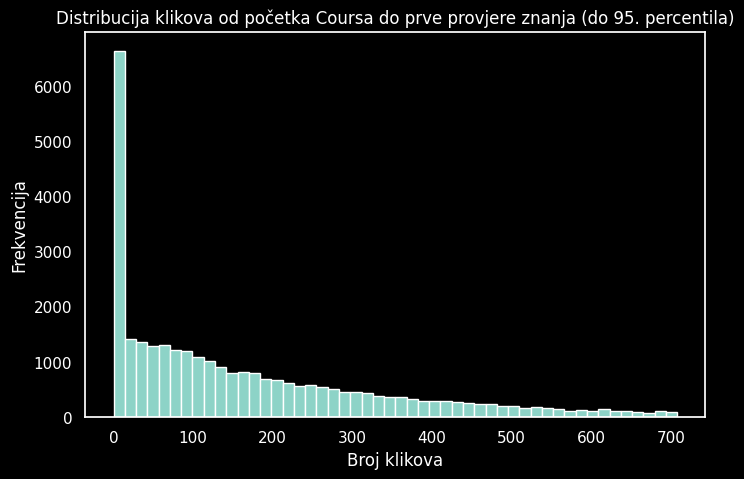

In [68]:
x = df["clicks_from_course_start_until_first_assessment"]

upper = np.percentile(x, 95)

plt.figure(figsize=(8, 5))
plt.hist(x[x <= upper], bins=50)
plt.title("Distribucija klikova od početka Coursa do prve provjere znanja (do 95. percentila)")
plt.xlabel("Broj klikova")
plt.ylabel("Frekvencija")
plt.grid(False)
plt.show()

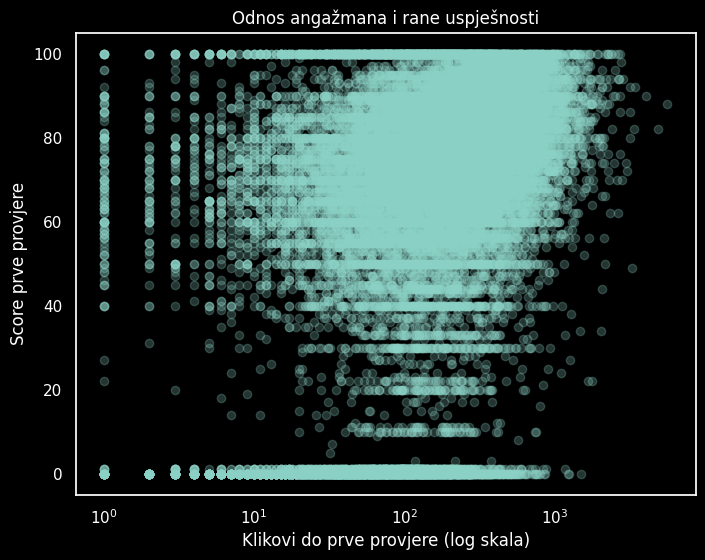

In [69]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["clicks_from_course_start_until_first_assessment"],
    df["score_first_assessment"],
    alpha=0.25
)

plt.xscale("log")
plt.xlabel("Klikovi do prve provjere (log skala)")
plt.ylabel("Score prve provjere")
plt.title("Odnos angažmana i rane uspješnosti")
plt.grid(False)

plt.show()

## Analiza korelacija

Kako bi se ispitao odnos između numeričkih značajki, izračunata je Pearsonova
korelacijska matrica za rane indikatore uspjeha i angažmana.


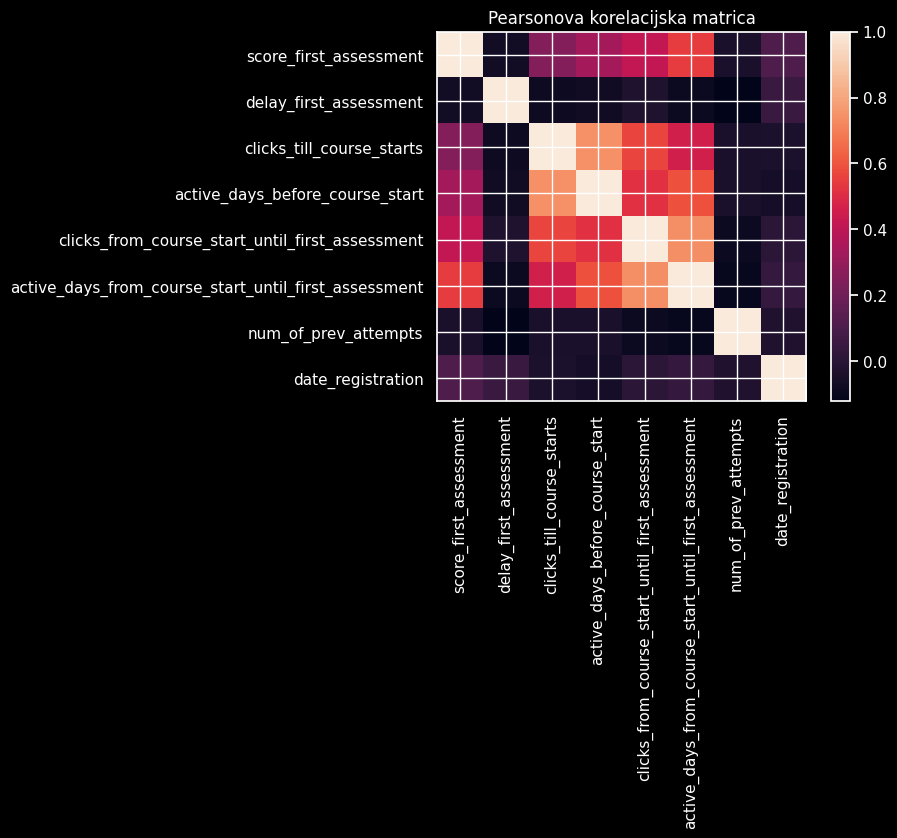

In [70]:
import numpy as np

corr_cols = [
    "score_first_assessment",
    "delay_first_assessment",
    "clicks_till_course_starts",
    "active_days_before_course_start",
    "clicks_from_course_start_until_first_assessment",
    "active_days_from_course_start_until_first_assessment",
    "num_of_prev_attempts",
    "date_registration"
]

corr = df[corr_cols].corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Pearsonova korelacijska matrica")
plt.show()

## Pregled nedostajućih vrijednosti

U nastavku se prikazuje udio nedostajućih vrijednosti po stupcima. Ove
vrijednosti će se obraditi u sljedećem koraku pripreme podataka.

In [76]:
missing_ratio = (
    df.isnull()
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
      .reset_index()
)
missing_ratio.columns = ["Stupac", "Nedostajuće vrijednosti (%)"]
missing_ratio

,Stupac,Nedostajuće vrijednosti (%)
0,delay_first_assessment,22.12
1,date_registration,0.14
2,id_student,0.00
3,code_module,0.00
4,code_presentation,0.00
5,age_band,0.00
6,gender,0.00
7,final_result,0.00
8,highest_education,0.00
9,num_of_prev_attempts,0.00


## Zaključak eksplorativne analize podataka (EDA)

Provedena eksplorativna analiza pokazala je da konstruirani skup podataka `early_predictors_final` sadrži smislen i informativan skup značajki za ranu predikciju akademskog uspjeha studenata.

Analiza raspodjele ciljne varijable (`final_result`) otkriva umjerenu neuravnoteženost klasa, što je očekivano u obrazovnim podacima te predstavlja važnu napomenu za kasniju fazu modeliranja.

Rezultat prve provjere znanja (`score_first_assessment`) pokazao se kao snažan rani indikator konačnog ishoda kolegija, s jasnim razlikama u distribucijama između uspješnih i neuspješnih studenata. Slično tome, kašnjenje prve predaje (`delay_first_assessment`) sadrži signal povezan s organiziranošću i angažmanom studenta, pri čemu su ekstremne vrijednosti rijetke i ne predstavljaju većinu populacije.

Analiza angažmana u VLE sustavu pokazuje izrazito desno asimetrične distribucije klikova, što je tipično za ovakve podatke. Primjena logaritamske skale omogućila je jasniji uvid u odnos između angažmana i rane uspješnosti, pri čemu se uočava pozitivan, ali ne deterministički odnos.

Korelacijska analiza potvrdila je snažne veze između različitih mjera angažmana (klikovi i aktivni dani), što ukazuje na potencijalnu multikolinearnost, ali i na konzistentnost mjerenja angažmana. Istovremeno, administrativne varijable poput datuma registracije i broja prethodnih pokušaja pokazuju slabije, ali potencijalno korisne signale.

Pregled nedostajućih vrijednosti pokazuje da se one pojavljuju gotovo isključivo kod varijable `delay_first_assessment`, što odgovara studentima koji nisu predali prvu provjeru znanja. Takve nedostajuće vrijednosti nisu slučajne, već nose informaciju o neangažiranosti studenta, te se stoga u ovoj fazi ne uklanjaju niti imputiraju proizvoljno. Varijabla `date_registration` sadrži zanemariv udio nedostajućih vrijednosti (≈0.14%), koji je najvjerojatnije posljedica administrativnih razloga. Nedostajanje ne nosi informativnu vrijednost, pa će se u fazi pripreme za modeliranje riješiti jednostavnom imputacijom (npr. medijanom).



Zaključno, provedena EDA je dovoljno opsežna i informativna, jasno povezana s ciljem rane predikcije uspjeha te predstavlja čvrstu osnovu za sljedeći korak – pripremu podataka i izgradnju modela strojnog učenja.

# Priprema podataka za modele strojnog učenja (ML-ready skup)

U ovom poglavlju pripremamo analitičku tablicu `early_predictors_final` za rad s ML modelima. Cilj je dobiti numerički “model-ready” skup (`early_predictors_ml`) uz jasnu evidenciju svih transformacija.

Što radimo:
- imputacija nedostajućih vrijednosti (prema dogovoru i najboljim praksama),
- dodavanje indikator-stupaca za nedostajanje (kako model ne bi “izgubio” informaciju da je nešto nedostajalo),
- one-hot enkodiranje kategorijskih varijabli,
- odabir i smislen raspored stupaca,
- spremanje ML skupa i tekstualne dokumentacije transformacija u `processed_data/`.

Napomena:
- `score_first_assessment` je već postavljen na 0 kad nema predaje prve provjere (to zadržavamo).
- `date_registration` ima vrlo malo missing vrijednosti - imputiramo medijanom.
- `delay_first_assessment` nedostaje kad nema predaje - dodajemo indikator `delay_first_assessment_missing`, a samu vrijednost imputiramo medijanom (model ima i vrijednost i signal da je bila missing).


In [77]:
# Postavke putanja i naziva
INPUT_PATH = "processed_data/early_predictors_final.parquet"   # ili .csv (prilagodi ako treba)
OUTPUT_DIR = "processed_data"
OUTPUT_PARQUET = os.path.join(OUTPUT_DIR, "early_predictors_ml.parquet")
OUTPUT_CSV = os.path.join(OUTPUT_DIR, "early_predictors_ml.csv")
TRANSFORM_LOG = os.path.join(OUTPUT_DIR, "early_predictors_ml_transformations.txt")

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Učitavanje podataka
if INPUT_PATH.endswith(".parquet"):
    df = pd.read_parquet(INPUT_PATH)
elif INPUT_PATH.endswith(".csv"):
    df = pd.read_csv(INPUT_PATH)
else:
    raise ValueError("INPUT_PATH mora biti .csv ili .parquet")

# Osnovno čišćenje (sigurno)
cat_cols = df.select_dtypes(include=["object"]).columns
for c in cat_cols:
    df[c] = df[c].astype(str).str.strip()

# 1) Missing vrijednosti + indikatori
transform_notes = []
transform_notes.append("ML priprema skupa early_predictors_final -> early_predictors_ml")
transform_notes.append("")
transform_notes.append("1) Missing vrijednosti i imputacija")

if "date_registration" in df.columns:
    df["date_registration_missing"] = df["date_registration"].isna().astype(int)
    med_reg = df["date_registration"].median(skipna=True)
    df["date_registration"] = df["date_registration"].fillna(med_reg)
    transform_notes.append(f"- date_registration: dodan indikator date_registration_missing; imputacija medijanom ({med_reg:.3f}).")

if "delay_first_assessment" in df.columns:
    df["delay_first_assessment_missing"] = df["delay_first_assessment"].isna().astype(int)
    med_delay = df["delay_first_assessment"].median(skipna=True)
    df["delay_first_assessment"] = df["delay_first_assessment"].fillna(med_delay)
    transform_notes.append(
        f"- delay_first_assessment: dodan indikator delay_first_assessment_missing; imputacija medijanom ({med_delay:.3f})."
    )

if "score_first_assessment" in df.columns:
    missing_score_before = df["score_first_assessment"].isna().sum()
    df["score_first_assessment"] = df["score_first_assessment"].fillna(0)
    transform_notes.append(f"- score_first_assessment: missing -> 0 (broj imputiranih: {missing_score_before}).")

# 2) Definicija ciljne varijable
transform_notes.append("")
transform_notes.append("2) Ciljna varijabla")
transform_notes.append("- final_result se zadržava kao multiclass cilj (bez enkodiranja u ovoj fazi).")

# 3) One-hot enkodiranje kategorijskih značajki
transform_notes.append("")
transform_notes.append("3) Enkodiranje kategorijskih varijabli (one-hot)")

META_COLS = ["id_student", "code_module", "code_presentation"]

# Kategorije za one-hot (bez meta i bez cilja)
TARGET_COL = "final_result"
categorical_to_encode = [
    c for c in df.select_dtypes(include=["object"]).columns
    if c not in META_COLS + [TARGET_COL]
]

# One-hot
df_encoded = pd.get_dummies(df, columns=categorical_to_encode, drop_first=False)
transform_notes.append(f"- One-hot enkodirane varijable: {', '.join(categorical_to_encode) if categorical_to_encode else '(nema)'}")
transform_notes.append("- drop_first=False (model može sam regularizirati; kasnije po potrebi možeš promijeniti).")

# 4) Smislen redoslijed stupaca
transform_notes.append("")
transform_notes.append("4) Redoslijed stupaca")
transform_notes.append("- Redoslijed: META (id + course) -> TARGET -> numeričke -> indikatori missing -> one-hot stupci")

# META + TARGET
cols_order = []
for c in META_COLS:
    if c in df_encoded.columns:
        cols_order.append(c)
if TARGET_COL in df_encoded.columns:
    cols_order.append(TARGET_COL)

# Numeričke (osim targeta)
numeric_cols = df_encoded.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in cols_order]

missing_flags = [c for c in numeric_cols if c.endswith("_missing")]
numeric_main = [c for c in numeric_cols if c not in missing_flags]

remaining = [c for c in df_encoded.columns if c not in cols_order + numeric_main + missing_flags]

final_cols = cols_order + numeric_main + missing_flags + remaining
df_encoded = df_encoded[final_cols]

# 5) Spremanje
df_encoded.to_parquet(OUTPUT_PARQUET, index=False)
df_encoded.to_csv(OUTPUT_CSV, index=False)

transform_notes.append("")
transform_notes.append("5) Spremanje")
transform_notes.append(f"- Parquet: {OUTPUT_PARQUET}")
transform_notes.append(f"- CSV: {OUTPUT_CSV}")

with open(TRANSFORM_LOG, "w", encoding="utf-8") as f:
    f.write("\n".join(transform_notes))

print("ML-ready dataset spremljen.")
print(OUTPUT_PARQUET)
print(OUTPUT_CSV)
print(TRANSFORM_LOG)


ML-ready dataset spremljen.
processed_data/early_predictors_ml.parquet
processed_data/early_predictors_ml.csv
processed_data/early_predictors_ml_transformations.txt


# Istraživačka pitanja, hipoteze i moguća poboljšanja znanstvenog rada

Primarni cilj ovog projekta je ponovna implementacija i provjera rezultata
znanstvenog rada *“Early Predictor for Student Success Based on Behavioural and
Demographical Indicators”*. Uz replikaciju izvornog pristupa, projekt ima i
širi istraživački cilj koji uključuje kritičko preispitivanje metodoloških
odluka autora te ispitivanje alternativnih pristupa modeliranju, evaluaciji i
interpretaciji rezultata.

### Formulacija klasifikacijskog problema
Autori rada problem predikcije uspjeha formuliraju korištenjem one-vs-rest
pristupa, pri čemu se treniraju zasebni binarni klasifikatori za svaku klasu.
Postavlja se hipoteza da bi izravna primjena višeklasnih (multiclass)
klasifikatora mogla dovesti do stabilnijih, jednostavnijih i interpretabilnijih
rezultata, uz istovremeno izbjegavanje problema povezanih s neuravnoteženošću
klasa i agregacijom binarnih odluka.

### Izbor prediktivnih modela
Rad razmatra ograničen skup modela (Decision Tree, Random Forest i BART).
Postavlja se hipoteza da bi primjena drugih algoritama, poput logističke
regresije, SVM-a ili naprednih ensemble metoda (npr. AdaBoost, XGBoost),
mogla rezultirati usporedivim ili boljim performansama. Time se ispituje u
kojoj mjeri zaključci rada ovise o izboru algoritma, a ne o samoj strukturi
podataka.

### Izbor i informativnost značajki
U izvornom radu koristi se ograničen broj značajki. Pretpostavlja se da bi
uključivanje dodatnih dostupnih varijabli moglo poboljšati prediktivnu moć
modela. Istovremeno se ispituje međusobna korelacija značajki i njihova stvarna
informativnost, budući da dio varijabli može biti redundantnog ili slabog
prediktivnog značaja.

### Interpretacija ponašajnih varijabli
Posebna pažnja posvećena je varijablama koje opisuju ponašanje studenata u
virtualnom okruženju za učenje, osobito broju klikova. Autori rada sugeriraju
da veći broj interakcija implicira veći angažman i bolji akademski uspjeh.
Postavlja se hipoteza da se pritom radi o korelaciji, a ne nužno o
uzročno-posljedičnoj vezi, odnosno da uspješniji studenti prirodno češće koriste
sustav, dok samo povećanje broja klikova ne mora izravno dovesti do boljih
rezultata.

### Ograničenja skupa podataka
Konačno, razmatra se pitanje ima li dostupni skup podataka dovoljno informacija
za donošenje snažnih i općih zaključaka o uspjehu studenata. Online učenje
uključuje brojne vanjske čimbenike (motivaciju, prethodno znanje, privatne
obveze i stil učenja) koji nisu obuhvaćeni analiziranim podacima, što predstavlja
inherentno ograničenje istraživanja, kako je istaknuto i u samom radu.

### Smjernice za buduća poboljšanja
Na temelju navedenih hipoteza, dodatne smjernice za unapređenje istraživanja
uključuju analizu vremenskih obrazaca ponašanja umjesto isključivo agregiranih
mjera, ispitivanje nelinearnih odnosa između značajki i ishoda, provjeru
robusnosti modela na različitim podskupovima podataka te dublju analizu
interpretabilnosti modela kako bi se dobio jasniji uvid u razloge pojedinih
predikcija.


# Zaključak – priprema i eksplorativna analiza podataka

U drugom dijelu projekta provedena je sustavna priprema i eksplorativna analiza
podataka korištenih u znanstvenom radu *“Early Predictor for Student Success
Based on Behavioural and Demographical Indicators”*. Nakon pregleda svih
dostupnih tablica konstruiran je jedinstveni analitički skup podataka namijenjen
ranoj predikciji akademskog uspjeha studenata.

Analiza je pokazala da rezultat i kašnjenje prve provjere znanja predstavljaju
najsnažnije rane indikatore konačnog ishoda, dok varijable angažmana u
virtualnom okruženju za učenje nose dodatnu, ali ograničenu informaciju.
Distribucije ponašajnih varijabli izrazito su asimetrične, a pojedine mjere
angažmana međusobno su snažno povezane, što upućuje na potrebu pažljivog odabira
značajki u fazi modeliranja.

Nedostajuće vrijednosti analizirane su u kontekstu njihova značenja, pri čemu
je utvrđeno da dio njih nosi informativnu vrijednost, dok je dio posljedica
administrativnih razloga. Time je osigurana pravilna interpretacija podataka i
priprema za daljnju obradu.

Zaključno, pripremljeni skup podataka i provedena EDA predstavljaju čvrstu
osnovu za sljedeći dio projekta, koji uključuje izgradnju i evaluaciju modela
strojnog učenja.